In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score
import joblib
from tqdm import tqdm
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
warnings.filterwarnings('ignore')

In [2]:
cuda_available = torch.cuda.is_available()

print("=== GPU AVAILABILITY DIAGNOSTIC ===")
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    # Detailed GPU information for performance optimization
    print(f"\n=== GPU HARDWARE DETAILS ===")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Device: {torch.cuda.current_device()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

    # Memory analysis - critical for batch size optimization
    print(f"\n=== MEMORY CONFIGURATION ===")
    memory_allocated = torch.cuda.memory_allocated(0)
    memory_reserved = torch.cuda.memory_reserved(0)
    total_memory = torch.cuda.get_device_properties(0).total_memory

    print(f"Total GPU Memory: {total_memory / 1024**3:.2f} GB")
    print(f"Currently Allocated: {memory_allocated / 1024**2:.2f} MB")
    print(f"Currently Reserved: {memory_reserved / 1024**2:.2f} MB")
    print(f"Available Memory: {(total_memory - memory_reserved) / 1024**3:.2f} GB")

    # CUDA version compatibility
    print(f"\n=== SOFTWARE VERSIONS ===")
    print(f"PyTorch Version: {torch.__version__}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")
    print(f"cuDNN Enabled: {torch.backends.cudnn.enabled}")

else:
    print("\n=== CPU-ONLY CONFIGURATION ===")
    print("GPU acceleration not available. Training will use CPU.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


=== GPU AVAILABILITY DIAGNOSTIC ===
CUDA Available: True

=== GPU HARDWARE DETAILS ===
Number of GPUs: 1
Current GPU Device: 0
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU

=== MEMORY CONFIGURATION ===
Total GPU Memory: 6.00 GB
Currently Allocated: 0.00 MB
Currently Reserved: 0.00 MB
Available Memory: 6.00 GB

=== SOFTWARE VERSIONS ===
PyTorch Version: 2.10.0+cu130
CUDA Version: 13.0
cuDNN Version: 91200
cuDNN Enabled: True
Using device: cuda


# Stage 5 - Model Architecture and Training
## 5.1 - Data Loading

In [3]:
# --- Loading and Tenosirizing Data
PROCESSED_DIR=Path("../data/processed")

df_train=pd.read_csv(PROCESSED_DIR / "train_processed.csv")
df_test=pd.read_csv(PROCESSED_DIR / "test_processed.csv")
train_labels=pd.read_csv(PROCESSED_DIR / "train_labels.csv")

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

# --- Convert to tensors 
# All models operate on torch tensors. float32 is standard for neural nets —
# float64 is unnecessarily expensive and not supported by all torch ops.

X_train=torch.tensor(df_train.values, dtype=torch.float32)
X_test=torch.tensor(df_test.values,  dtype=torch.float32)

INPUT_DIM=X_train.shape[1]
print(f"Input dimensionality: {INPUT_DIM}")

Train shape: (125957, 42)
Test shape:  (22543, 42)
Input dimensionality: 42


## 5.2 - Soft Normal Filter
> Stage 2 flagged 27% of training records have flag=S0, indicating attack contamination
> Training anamoly detectors on contaminated data could shift the normal signals
> towards attack signals, degrading detection.
> We filter without using labels, purely on processed feature values
> For eg. if serror_rate_mean>0.5, it is a strong heuristic for SYN flood DOS records

In [4]:
serror_col=df_train.columns.get_loc('serror_rate_mean')
priv_col=df_train.columns.get_loc('privilege_escalation_signal')

serror_vals=X_train[:, serror_col]
priv_vals=X_train[:, priv_col]

# Filter mask, True = keep for training
normal_mask=(serror_vals < 0.5) & (priv_vals == 0)
X_train_normal=X_train[normal_mask]

print(f"Records before soft filter: {X_train.shape[0]}")
print(f"Records after soft filter:  {X_train_normal.shape[0]}")
print(f"Filtered out: {(~normal_mask).sum().item()} "
      f"({100*(~normal_mask).float().mean().item():.1f}%)")

Records before soft filter: 125957
Records after soft filter:  89015
Filtered out: 36942 (29.3%)


## 5.3 - Deep Isolation Forest

In [5]:
# --- Deep Isolation Forest 
# Inspired by Xu et al. (2023) "Deep Isolation Forest for Anomaly Detection"
#
# Core idea: instead of random axis-parallel cuts in original feature space,
# we first project data through randomly initialized (fixed, not trained)
# neural networks into multiple representation spaces. Random cuts are then
# applied in each projected space.
#
# Why this improves on classical iForest:
# Classical iForest uses axis-parallel splits — it can only isolate anomalies
# that differ along individual feature axes. In high-dimensional tabular data
# with correlated features (confirmed in Stage 3B), anomalies may only be
# separable in combinations of features (non-axis-aligned directions).
# Neural projections create random non-linear combinations of features,
# making the cuts effectively non-axis-parallel in original space.
#
# The projection networks are RANDOMLY INITIALIZED and FROZEN — they are
# not trained. Their purpose is to create diverse random representations,
# not to learn anything. This is analogous to the random hash functions
# in Locality Sensitive Hashing.

class RandomProjectionNetwork(nn.Module):
    """
    A single randomly initialized projection network.
    Weights are frozen after initialization: intentional.
    The network maps R^input_dim to R^proj_dim using random non-linear
    transformations, creating a diverse representation space for isolation.
    """

    def __init__(self, input_dim, proj_dim=64, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, proj_dim),
            nn.Tanh()
        )
        # Tanh over ReLU due to bounded output. prevents extreme projections that would isolate everything.

        # Freeze all params.
        for param in self.parameters():
            param.requires_grad=False
    def forward(self, x):
        return self.net(x)

class DeepIsolationForest(nn.Module):
    """
    Ensemble of random projection networks followed by isolation scoring.

    n_estimators: number of random projection networks (trees in classical iForest)
    proj_dim: dimensionality of each projected space
    n_samples: number of training samples used to build isolation reference
    max_samples: subsample size for each tree (classical iForest default: 256)
    """
    def __init__(self, input_dim, proj_dim=64, n_estimators=100, max_samples=256):
        super().__init__()
        self.n_estimators=n_estimators
        self.max_samples=max_samples
        self.proj_dim=proj_dim

        # Ensemble of projection modules using Modulelist

        self.projectors=nn.ModuleList([
            RandomProjectionNetwork(input_dim, proj_dim) for _ in range(n_estimators)
        ])

        # Ref sample, stored after fit(), using during score()
        # Subsampled training points in each projected space
        self.register_buffer('reference_projections', torch.zeros(n_estimators, max_samples, proj_dim))
        self.is_fitted = False

    def fit(self, X):
        """
        Store random projections of subsampled training data.
        This is the 'training' step — no gradient computation needed.
        X: tensor of shape (n_samples, input_dim)
        """
        self.eval()
        with torch.no_grad():
            n = X.shape[0]
            for i, projector in enumerate(tqdm(self.projectors, desc="Fitting DIF trees")):
                # Subsample max_samples records for this tree
                idx = torch.randperm(n)[:self.max_samples]
                X_sub = X[idx].to(device)
                self.reference_projections[i] = projector(X_sub)
        self.is_fitted = True
        print(f"Deep Isolation Forest fitted on {n} samples.")

    def score_samples(self, x):
        """
        Compute anomaly scores for input X.
        Score = mean isolation depth across all trees.
        Lower path length = easier to isolate = more anomalous.
        We negate so that higher score = more anomalous (consistent
        convention with sklearn's decision_function).

        Returns: anomaly scores tensor of shape (n_samples,)
        """
        assert self.is_fitted, "Call fit() before score_samples()"
        self.eval()
        all_scores=[]
        with torch.no_grad():
            x=x.to(device)
            for i, projector in enumerate(tqdm(self.projectors, desc="Scoring DIF trees")):
                # Project input into this tree's representation space
                x_proj=projector(x)                 # (n, proj_dim)
                refs=self.reference_projections[i]  # (max_samples, proj_dim)

                # Compute pairwise distances between X_proj and reference points
                # Using squared Euclidean distance for efficiency
                # Shape: (n, max_samples)
                dists = torch.cdist(x_proj, refs, p=2)

                # Isolation score proxy: mean distance to k nearest references
                # Points far from all references = easy to isolate = anomalous
                # We use k=8 nearest neighbors as the isolation proxy
                k = min(8, refs.shape[0])
                knn_dists, _ = dists.topk(k, dim=1, largest=False)
                tree_score = knn_dists.mean(dim=1)  # (n,)
                all_scores.append(tree_score)
        scores=torch.stack(all_scores, dim=0).mean(dim=0)
        return scores.cpu()

In [6]:
# <--- DIF Training --->

torch.manual_seed(42)
dif_model = DeepIsolationForest(
    input_dim=INPUT_DIM,
    n_estimators=100,
    proj_dim=64,
    max_samples=256
).to(device)

test_input = torch.randn(5, INPUT_DIM).to(device)
print(dif_model.projectors[0](test_input).shape)

dif_model.fit(X_train_normal.to(device))


# Compute scores on full training set and test sets
dif_scores_train=dif_model.score_samples(X_train)
dif_scores_test=dif_model.score_samples(X_test)

print(f"DIF score range (train): "
      f"[{dif_scores_train.min():.4f}, {dif_scores_train.max():.4f}]")
print(f"DIF score range (test):  "
      f"[{dif_scores_test.min():.4f}, {dif_scores_test.max():.4f}]")

torch.Size([5, 64])


Fitting DIF trees: 100%|████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 535.82it/s]

Deep Isolation Forest fitted on 89015 samples.



Scoring DIF trees: 100%|████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 795.16it/s]


DIF score range (train): [0.0776, 2.5223]
DIF score range (test):  [0.0784, 2.4619]


## 5.4 - Variational Encoder (B-VAE)

In [9]:
# --- B-VAE 
# Architecture motivated by Stage 3B's two-world finding:
# behavioral features (sparse, binary) and traffic features (continuous)
# form two structurally distinct information worlds.
# We implement a dual-stream encoder that processes each world separately
# before merging at the bottleneck — this lets each stream develop
# appropriate internal representations without cross-contamination.
#
# Two anomaly signals:
# 1. Reconstruction error (MSE): poor reconstruction = anomalous
# 2. KL divergence: distance from standard normal in latent space
#    A record that maps to an unusual latent position is anomalous
#    even if it reconstructs well (important for subtle anomalies)
#
# B parameter controls the weight of the KL term relative to reconstruction.
# B > 1 encourages a more disentangled, structured latent space.
# We use β = 2 — slightly above standard VAE (β=1) to encourage
# the latent space to reflect the two-world structure.

# --- Feature stream definitions 
# Stream 1: Traffic/rate/volume features (continuous, right branch of dendrogram)
# Stream 2: Behavioral/content features (sparse, binary, left branch)

feature_names=df_train.columns.tolist()

STREAM_1_FEATURES = [
    'src_bytes', 'dst_bytes', 'duration', 'srv_count', 'count',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'serror_rate_mean', 'rerror_rate_mean', 'same_srv_scope_delta',
    'service_freq', 'proto_icmp', 'proto_tcp', 'proto_udp',
    'flag_REJ', 'flag_RSTO', 'flag_RSTR', 'flag_S0', 'flag_SF',
    'flag_flag_rare'
]

STREAM_2_FEATURES = [
    'privilege_escalation_signal', 'hot', 'num_file_creations',
    'num_access_files', 'root_shell', 'land', 'is_guest_login',
    'is_host_login', 'su_attempted', 'wrong_fragment', 'urgent',
    'num_shells', 'logged_in', 'num_outbound_cmds', 'is_rare_service_flag',
    'num_failed_logins'
]

# Col indices for each stream
s1_idx=[feature_names.index(f) for f in STREAM_1_FEATURES if f in feature_names]
s2_idx=[feature_names.index(f) for f in STREAM_2_FEATURES if f in feature_names]

S1_DIM, S2_DIM=len(s1_idx), len(s2_idx)
LATENT_DIM=16 #Bottlenecked size

# Bottleneck justification:
# Input = ~42 features. A common heuristic is latent_dim ≈ input_dim / 3
# to force meaningful compression. 16 is slightly more aggressive than
# 42/3 ≈ 14, pushing the model to learn a tighter normal representation.
# Too small (< 8): underfits normal traffic, high reconstruction error
# for everything including normal — useless anomaly signal.
# Too large (> 24): memorizes rather than compresses — anomalies
# reconstruct well, killing the anomaly signal.

print(f"Stream 1 dimension: {S1_DIM}")
print(f"Stream 2 dimension: {S2_DIM}")
print(f"Latent dimension:   {LATENT_DIM}")


Stream 1 dimension: 26
Stream 2 dimension: 16
Latent dimension:   16


In [19]:
class DualStreamVAE(nn.Module):
    # stream 1: traffic features -> hidden
    # stream 2: content features -> hidden
    # merged: concat both stream representations -> Shared latent space
    # decoder: latent -> reconstrcuted full feature vector

    # Anamoly Signals: recon_error: MSE b/2 output and input. kl_dic= divergence of posterior from N(0,1)

    def __init__(self, s1_dim, s2_dim, latent_dim, beta=2.0):
        super().__init__()
        self.s1_dim = s1_dim
        self.s2_dim = s2_dim
        self.latent_dim = latent_dim
        self.beta = beta
        total_dim = s1_dim + s2_dim

        # --- Stream 1 ---
        self.enc_s1=nn.Sequential(
            nn.Linear(s1_dim, 64),
            nn.LayerNorm(64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.LeakyReLU(0.1)
        )

        # --- Stream 2 ---
        self.enc_s2=nn.Sequential(
            nn.Linear(s2_dim, 32),
            nn.LayerNorm(32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, 16),
            nn.LayerNorm(16),
            nn.LeakyReLU(0.1)
        )

        merged_dim=16+32
        self.fc_mu=nn.Linear(merged_dim, latent_dim)
        self.fc_logvar=nn.Linear(merged_dim, latent_dim)

        # --- Decoder --- Symm to Encoder
        self.decoder=nn.Sequential(
            nn.Linear(latent_dim, 48),
            nn.LayerNorm(48),
            nn.LeakyReLU(0.1),
            nn.Linear(48,64),
            nn.LayerNorm(64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, total_dim)
        )

    def encode(self,x_s1, x_s2):
        h1=self.enc_s1(x_s1)
        h2=self.enc_s2(x_s2)
        merged=torch.cat([h1,h2],dim=1)
        mu=self.fc_mu(merged)
        logvar=self.fc_logvar(merged)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = mu + eps * sigma, eps ~ N(0,I)
        This allows gradients to flow through the sampling operation.
        At inference time we can use mu directly (eps=0) for deterministic
        anomaly scoring — we do this in score_samples().
        """
        if self.training:
            std=torch.exp(0.5*logvar)
            eps=torch.randn_like(std)
            return mu+eps*std
        else:
            return mu

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x_s1, x_s2):
        mu, logvar=self.encode(x_s1, x_s2)
        z=self.reparameterize(mu, logvar)
        recon=self.decode(z)
        return recon, mu, logvar

    def vae_loss(self, recon, x_full, mu, logvar):
        """
        B-VAE loss = Reconstruction loss + β * KL divergence
        Reconstruction: MSE over all features
        KL: closed-form for Gaussian posterior vs N(0,I) prior
          KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
        """
        recon_loss = nn.functional.mse_loss(recon, x_full, reduction='mean')
        kl_loss = -0.5*torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        return recon_loss + self.beta*kl_loss, recon_loss, kl_loss

    def score_samples(self, x_s1, x_s2):
        # Returns recon_score and kl_score per sample as detached numpy arrays
        self.eval()
        with torch.no_grad():
            mu, logvar=self.encode(x_s1, x_s2)
            z=mu
            recon=self.decode(z)
            x_full=torch.cat([x_s1, x_s2], dim=1)

            # per sample recon
            recon_score=((recon - x_full)**2).mean(dim=1)

            # per sample kl
            kl_score = -0.5*(1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1)

            return recon_score.cpu().numpy(), kl_score.cpu().numpy()


In [20]:
# --- B-VAE Training ---
def get_stream_tensors(X, s1_idx, s2_idx, dev):
    return (X[:, s1_idx].to(dev), X[:, s2_idx].to(dev))

vae_model=DualStreamVAE(
    s1_dim=S1_DIM,
    s2_dim=S2_DIM,
    latent_dim=LATENT_DIM,
    beta=2.0
).to(device)

optimizer=optim.Adam(vae_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

BATCH_SIZE=512
train_dataset=TensorDataset(X_train_normal)
train_loader=DataLoader(train_dataset, batch_size=BATCH_SIZE,shuffle=True, drop_last=True)

# --- Training Loop ---
N_EPOCHS=50
best_loss = float('inf')
best_state = None
history = []

print(f"Training B-VAE for {N_EPOCHS} epochs...")
print(f"Batch size: {BATCH_SIZE} | "
      f"Batches per epoch: {len(train_loader)}")

epoch_bar=tqdm(range(N_EPOCHS), desc="VAE Training")
for epoch in epoch_bar:
    vae_model.train()
    epoch_loss=epoch_recon=epoch_kl=0.0

    for (batch,) in train_loader:
        x_s1, x_s2=get_stream_tensors(batch, s1_idx, s2_idx, device)
        x_full=batch.to(device)
        optimizer.zero_grad()
        recon, mu, logvar=vae_model(x_s1, x_s2)
        loss, recon_l, kl_l=vae_model.vae_loss(recon, x_full, mu, logvar)
        loss.backward()

        # --- Grad Clip ---
        torch.nn.utils.clip_grad_norm_(vae_model.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss+=loss.item()
        epoch_recon+=recon_l.item()
        epoch_kl+=kl_l.item()

    n_batches=len(train_loader)
    avg_loss=epoch_loss/n_batches
    avg_recon=epoch_recon/n_batches
    avg_kl=epoch_kl/n_batches

    scheduler.step(avg_loss)
    history.append({
        "epoch":epoch+1,
        'loss': avg_loss,
        "recon":avg_recon,
        "kl":avg_kl
    })

    #save best model
    if avg_loss<best_loss:
        best_loss = avg_loss
        best_state = {k: v.clone() for k, v in vae_model.state_dict().items()}

    epoch_bar.set_postfix({
        'epoch': f"{epoch+1}/{N_EPOCHS}",
        'loss':  f"{avg_loss:.4f}",
        'recon': f"{avg_recon:.4f}",
        'kl':    f"{avg_kl:.4f}"
    })

# Restore best model
vae_model.load_state_dict(best_state)
print(f"\nBest loss: {best_loss:.4f} — best weights restored.")

# Score all splits

for name, X in [('train', X_train), ('test', X_test)]:
    xs1, xs2=get_stream_tensors(X, s1_idx, s2_idx, device)
    r, k = vae_model.score_samples(xs1, xs2)
    print(f"VAE scores ({name}) — "
          f"Recon: [{r.min():.4f}, {r.max():.4f}] | "
          f"KL: [{k.min():.4f}, {k.max():.4f}]")

vae_recon_train, vae_kl_train=vae_model.score_samples(*get_stream_tensors(X_train, s1_idx, s2_idx, device))

vae_recon_test, vae_kl_test=vae_model.score_samples(*get_stream_tensors(X_test,  s1_idx, s2_idx, device))
    

Training B-VAE for 50 epochs...
Batch size: 512 | Batches per epoch: 173


VAE Training: 100%|█████████████████| 50/50 [01:29<00:00,  1.79s/it, epoch=50/50, loss=0.4842, recon=0.1808, kl=0.1517]



Best loss: 0.4842 — best weights restored.
VAE scores (train) — Recon: [0.1530, 135.6827] | KL: [0.5928, 12.0850]
VAE scores (test) — Recon: [0.1543, 133.4272] | KL: [0.6096, 11.8490]


## 5.5 - One-Class SVM

In [22]:
from sklearn.svm import OneClassSVM

OCSVM_SUBSAMPLE = 15000
torch.manual_seed(42)
np.random.seed(42)

# Subsample from filtered normal training data
n_normal=X_train_normal.shape[0]
sub_idx=np.random.choice(n_normal,size=min(OCSVM_SUBSAMPLE, n_normal),replace=False)
X_ocsvm_fit=X_train_normal[sub_idx].numpy()

ocsvm_model=OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
ocsvm_model.fit(X_ocsvm_fit)
print(f"OCSVM fitted on {len(sub_idx)} samples.")

# decision_function returns signed distance to the boundary.
# Negative = outside boundary = anomalous.
# negate so higher score = more anomalous (consistent with DIF convention).
ocsvm_scores_train=-ocsvm_model.decision_function(X_train.numpy())
ocsvm_scores_test=-ocsvm_model.decision_function(X_test.numpy())

print(f"OCSVM score range (train): "
      f"[{ocsvm_scores_train.min():.4f}, {ocsvm_scores_train.max():.4f}]")
print(f"OCSVM score range (test):  "
      f"[{ocsvm_scores_test.min():.4f}, {ocsvm_scores_test.max():.4f}]")

OCSVM fitted on 15000 samples.
OCSVM score range (train): [-27.4283, 64.5286]
OCSVM score range (test):  [-25.9690, 63.9338]


## 5.6 - Saving Models 

In [23]:
# --- Save all model states 
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# DIF: save full model (architecture + weights + reference projections)
torch.save(dif_model.state_dict(), MODELS_DIR / "dif_model.pt")

# VAE: save best weights + architecture config
torch.save({
    'state_dict': best_state,
    'config': {
        's1_dim': S1_DIM, 's2_dim': S2_DIM,
        'latent_dim': LATENT_DIM, 'beta': 2.0
    },
    'history': history,
    's1_idx': s1_idx,
    's2_idx': s2_idx
}, MODELS_DIR / "vae_model.pt")

# OCSVM: joblib (sklearn models don't use torch save)
joblib.dump(ocsvm_model, MODELS_DIR / "ocsvm_model.joblib")

# Raw scores — save for Stage 6 ensemble construction
scores = {
    'dif_train':        dif_scores_train.numpy(),
    'dif_test':         dif_scores_test.numpy(),
    'vae_recon_train':  vae_recon_train,
    'vae_recon_test':   vae_recon_test,
    'vae_kl_train':     vae_kl_train,
    'vae_kl_test':      vae_kl_test,
    'ocsvm_train':      ocsvm_scores_train,
    'ocsvm_test':       ocsvm_scores_test,
}
joblib.dump(scores, MODELS_DIR / "base_scores.joblib")

print("All models and scores saved.")
for f in sorted(MODELS_DIR.iterdir()):
    print(f"  {f.name:<35} {f.stat().st_size/1024:>8.1f} KB")

All models and scores saved.
  base_scores.joblib                    2901.1 KB
  dif_model.pt                         11923.3 KB
  ocsvm_model.joblib                     267.7 KB
  vae_model.pt                            65.8 KB


## 5.7 - Score Distributions

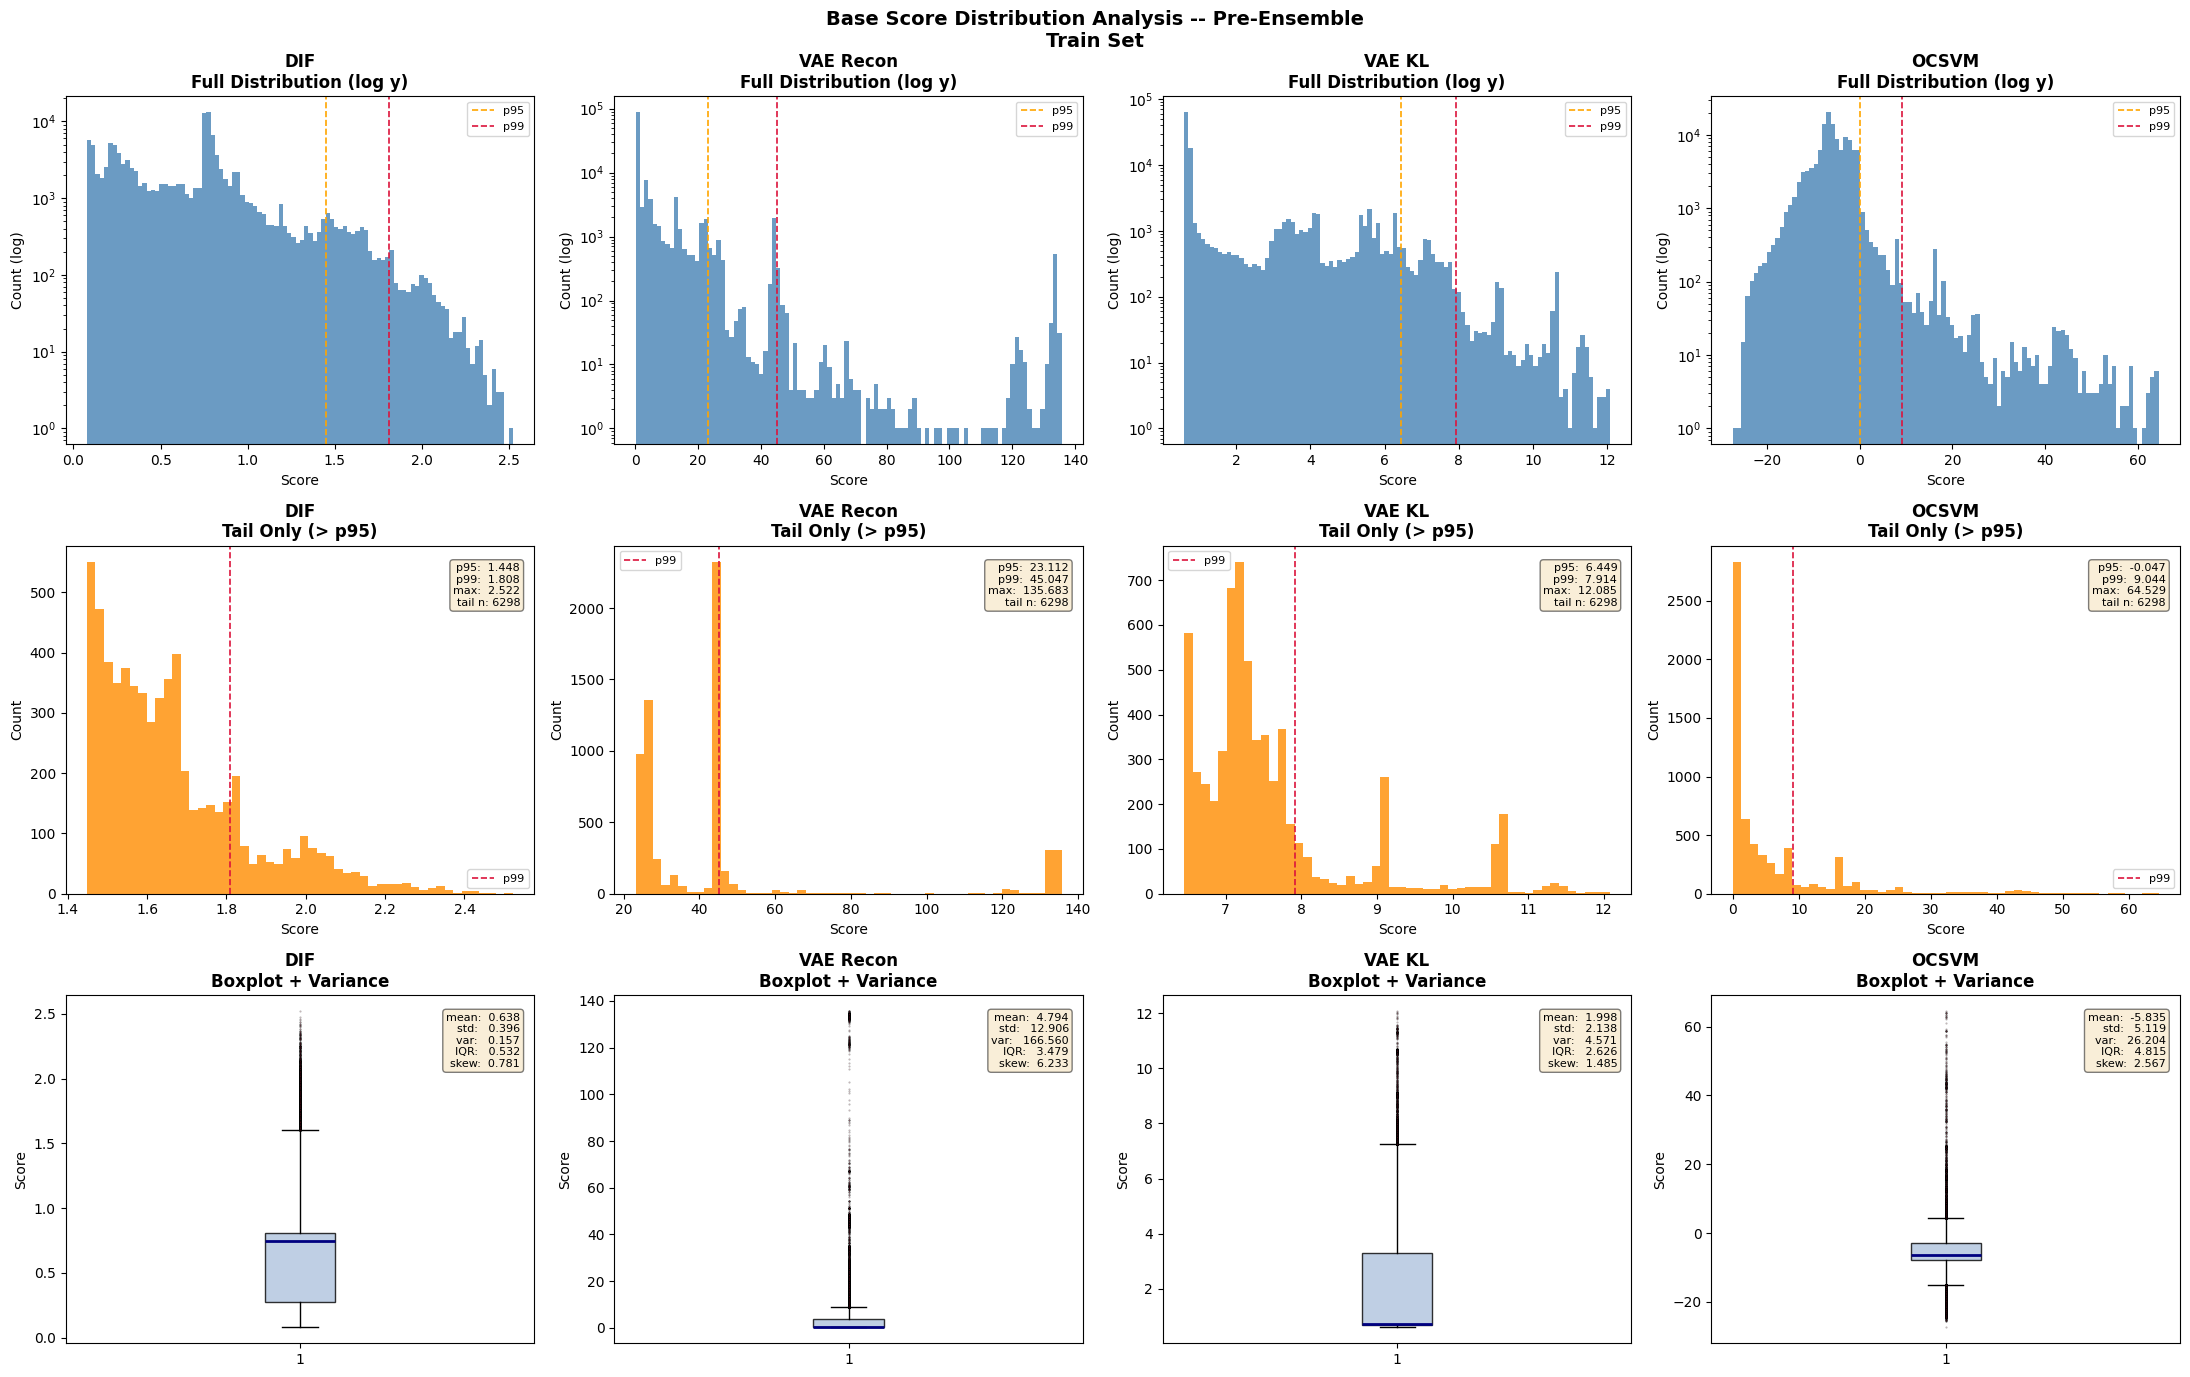


Percentile breakdown across all base scores:
Percentile              DIF      VAE Recon         VAE KL          OCSVM
------------------------------------------------------------------------
p50                  0.7469         0.2917         0.7067        -6.2417
p75                  0.8075         3.7030         3.3077        -2.9746
p90                  1.0865        14.0185         5.6095        -1.0454
p95                  1.4483        23.1123         6.4489        -0.0470
p99                  1.8080        45.0471         7.9144         9.0440
p99.5                1.9708       123.5553         9.1002        16.7620
p100                 2.5223       135.6827        12.0850        64.5286


In [27]:
# ── Collect all base scores 
score_dict = {
    'DIF':       dif_scores_train.numpy(),
    'VAE Recon': vae_recon_train,
    'VAE KL':    vae_kl_train,
    'OCSVM':     ocsvm_scores_train
}

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
fig.suptitle('Base Score Distribution Analysis -- Pre-Ensemble\nTrain Set', fontsize=14, fontweight='bold')

for col_idx, (name, scores) in enumerate(score_dict.items()):

    # ── Row 1: Full distribution (log y-scale) 
    ax = axes[0, col_idx]
    ax.hist(scores, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_yscale('log')
    ax.set_title(f'{name}\nFull Distribution (log y)', fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count (log)')
    ax.axvline(np.percentile(scores, 95), color='orange',linestyle='--', linewidth=1.2, label='p95')
    ax.axvline(np.percentile(scores, 99), color='crimson',linestyle='--', linewidth=1.2, label='p99')
    ax.legend(fontsize=8)

    # ── Row 2: Tail zoom (above 95th percentile) 
    ax=axes[1, col_idx]
    p95=np.percentile(scores, 95)
    tail=scores[scores > p95]
    ax.hist(tail, bins=50, color='darkorange', edgecolor='none', alpha=0.8)
    ax.set_title(f'{name}\nTail Only (> p95)', fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')

    # Annotate with tail statistics
    ax.axvline(np.percentile(scores, 99), color='crimson', linestyle='--', linewidth=1.2, label='p99')
    ax.text(0.97, 0.95,
            f'p95:  {np.percentile(scores, 95):.3f}\n'
            f'p99:  {np.percentile(scores, 99):.3f}\n'
            f'max:  {scores.max():.3f}\n'
            f'tail n: {len(tail)}',
            transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.legend(fontsize=8)

    # ── Row 3: Box + variance summary 
    ax = axes[2, col_idx]
    ax.boxplot(scores, 
               vert=True, 
               patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue', alpha=0.8),
               flierprops=dict(marker='.', markersize=1, markerfacecolor='crimson', alpha=0.3),
               medianprops=dict(color='navy', linewidth=2)
              )
    ax.set_title(f'{name}\nBoxplot + Variance', fontweight='bold')
    ax.set_ylabel('Score')

    # Annotate with variance stats
    ax.text(0.97, 0.95,
            f'mean:  {scores.mean():.3f}\n'
            f'std:   {scores.std():.3f}\n'
            f'var:   {scores.var():.3f}\n'
            f'IQR:   {np.percentile(scores,75)-np.percentile(scores,25):.3f}\n'
            f'skew:  {float(pd.Series(scores).skew()):.3f}',
            transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../outputs/score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Percentile table 
print("\nPercentile breakdown across all base scores:")
print(f"{'Percentile':<12}", end="")
for name in score_dict:
    print(f"{name:>15}", end="")
print()
print("-" * 72)

for p in [50, 75, 90, 95, 99, 99.5, 100]:
    print(f"p{p:<11}", end="")
    for scores in score_dict.values():
        print(f"{np.percentile(scores, p):>15.4f}", end="")
    print()